<a href="https://colab.research.google.com/github/NataliiaHromyk/HomeWork_Python_DS/blob/main/Hromyk_%22HW_2_4_kNN_%D0%9A%D1%80%D0%BE%D1%81%D0%B2%D0%B0%D0%BB%D1%96%D0%B4%D0%B0%D1%86%D1%96%D1%8F_%D1%96_%D1%82%D1%8E%D0%BD%D0%B8%D0%BD%D0%B3_%D0%B3%D1%96%D0%BF%D0%B5%D1%80%D0%BF%D0%B0%D1%80%D0%B0%D0%BC%D0%B5%D1%82%D1%80%D1%96%D0%B2_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

0. Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

[process_bank_churn](https://github.com/NataliiaHromyk/HomeWork_Python_DS/blob/main/process_bank_churn.py)

In [1]:
!rm process_bank_churn.py

rm: cannot remove 'process_bank_churn.py': No such file or directory


In [2]:
!wget https://raw.githubusercontent.com/NataliiaHromyk/HomeWork_Python_DS/refs/heads/main/process_bank_churn.py

--2025-08-16 21:18:06--  https://raw.githubusercontent.com/NataliiaHromyk/HomeWork_Python_DS/refs/heads/main/process_bank_churn.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4625 (4.5K) [text/plain]
Saving to: ‘process_bank_churn.py’

process_bank_churn. 100%[===================>]   4.52K  --.-KB/s    in 0s      

2025-08-16 21:18:07 (68.9 MB/s) - ‘process_bank_churn.py’ saved [4625/4625]



In [3]:
import importlib
import process_bank_churn
importlib.reload(process_bank_churn)

<module 'process_bank_churn' from '/content/process_bank_churn.py'>

In [4]:
!pip install opendatasets --upgrade --quiet
import opendatasets as od
import pandas as pd
dataset_url = 'https://www.kaggle.com/competitions/bank-customer-churn-prediction-dlu-course-c-3'
od.download(dataset_url)
data_dir = './bank-customer-churn-prediction-dlu-course-c-3'
train_csv = data_dir + '/train.csv'
train_main_df = pd.read_csv(train_csv, index_col=0)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: nataliiahromyk
Your Kaggle Key: ··········


100%|██████████| 637k/637k [00:00<00:00, 733MB/s]


Extracting archive ./bank-customer-churn-prediction-dlu-course-c-3/bank-customer-churn-prediction-dlu-course-c-3.zip to ./bank-customer-churn-prediction-dlu-course-c-3


In [5]:
import process_bank_churn as pr

data = pr.preprocess_data(train_main_df, scale_numeric=False)

In [6]:
X_train = data['train_X']
train_targets = data['train_y']
X_val = data['val_X']
val_targets = data['val_y']

In [7]:
X_train

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
id,,,,,,,,,,,,,
7180,682.0,30.0,1.0,131394.56,1.0,1.0,1.0,143952.24,1.0,0.0,0.0,0.0,1.0
10393,684.0,39.0,2.0,178058.06,1.0,1.0,0.0,145518.31,1.0,0.0,0.0,1.0,0.0
80,705.0,35.0,6.0,116320.68,2.0,1.0,0.0,174431.01,0.0,1.0,0.0,0.0,1.0
3365,669.0,58.0,0.0,0.00,2.0,0.0,1.0,51565.98,0.0,0.0,1.0,0.0,1.0
12236,707.0,21.0,3.0,0.00,2.0,1.0,1.0,148564.76,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9493,633.0,33.0,4.0,0.00,2.0,0.0,0.0,123537.05,1.0,0.0,0.0,1.0,0.0
8463,673.0,40.0,1.0,0.00,1.0,1.0,1.0,47832.82,1.0,0.0,0.0,1.0,0.0
8143,621.0,29.0,8.0,0.00,2.0,1.0,1.0,133535.29,1.0,0.0,0.0,0.0,1.0


1. Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mlxtend.plotting import plot_decision_regions

from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score

In [9]:
?KNeighborsClassifier

In [10]:
knn = KNeighborsClassifier()
knn.fit(X_train, train_targets)

KNeighborsClassifier()

In [13]:
train_preds = knn.predict_proba(X_train)[:, 1]
auc_roc = roc_auc_score(train_targets, train_preds)

print(f"AUC-ROC Score for KNN train: {auc_roc:.4f}")

AUC-ROC Score for KNN train: 0.8238


In [14]:
val_preds = knn.predict_proba(X_val)[:, 1]
auc_roc = roc_auc_score(val_targets, val_preds)

print(f"AUC-ROC Score for KNN val: {auc_roc:.4f}")

AUC-ROC Score for KNN val: 0.5734


In [15]:
train_targets.value_counts() / len(train_targets)

,count
Exited,
0.0,0.7965
1.0,0.2035


In [16]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [17]:
accuracy_score(train_targets, np.round(train_preds)), accuracy_score(val_targets, np.round(val_preds))

(0.8195833333333333, 0.7756666666666666)

In [18]:
def predict_and_plot(inputs, targets, name=''):
    preds = knn.predict(inputs)

    accuracy = accuracy_score(targets, preds)
    print("Accuracy: {:.2f}%".format(accuracy * 100))

    cf = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(cf, annot=True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name));

    return preds

Accuracy: 81.96%


array([0., 0., 0., ..., 0., 0., 0.])

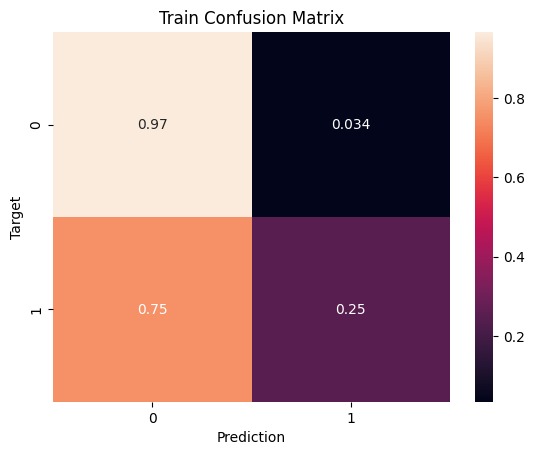

In [19]:
predict_and_plot(X_train, train_targets, 'Train')

Accuracy: 77.57%


array([1., 0., 0., ..., 0., 0., 1.])

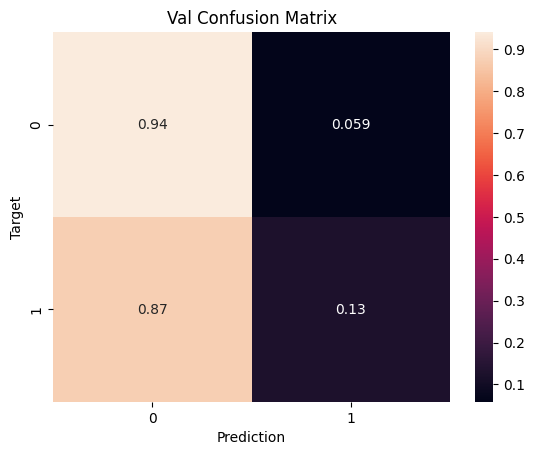

In [20]:
predict_and_plot(X_val, val_targets, 'Val')

Оцінивши модель ми чітко бачимо її недонавчання навіть на тренованих даних, оскільки 75% одиниць на трейні при предікшені ми називаємо нулями, а на валідаційних даних даний показник становить 87% - тобто, ми некоректно вгадуємо менший клас. Це говорить про неякісну модель.

2. Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [21]:
knn = KNeighborsClassifier()
params_knn = {'n_neighbors': np.arange(1, 13)}
knn_gs = GridSearchCV(knn, params_knn, cv=5)
knn_gs.fit(X_train, train_targets)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])})

In [22]:
knn_best = knn_gs.best_estimator_

print(knn_gs.best_params_, knn_gs.best_score_)

{'n_neighbors': np.int64(12)} 0.78825


In [23]:
knn_best = knn_gs.best_estimator_

In [24]:
train_preds = knn_best.predict_proba(X_train)[:, 1]
auc_roc = roc_auc_score(train_targets, train_preds)

print(f"AUC-ROC Score for knn_best train: {auc_roc:.4f}")

AUC-ROC Score for knn_best train: 0.7324


In [25]:
val_preds = knn_best.predict_proba(X_val)[:, 1]
auc_roc = roc_auc_score(val_targets, val_preds)

print(f"AUC-ROC Score for KNN val: {auc_roc:.4f}")

AUC-ROC Score for KNN val: 0.5978


In [26]:
def get_report(model, X_test, y_true):
    y_pred = model.predict(X_test)
    print(classification_report(y_true, y_pred, digits=4))

In [27]:
get_report(knn_best, X_train, train_targets)

              precision    recall  f1-score   support

         0.0     0.8021    0.9912    0.8867      9558
         1.0     0.5556    0.0430    0.0798      2442

    accuracy                         0.7983     12000
   macro avg     0.6788    0.5171    0.4833     12000
weighted avg     0.7520    0.7983    0.7225     12000



In [28]:
get_report(knn_best, X_val, val_targets)

              precision    recall  f1-score   support

         0.0     0.7989    0.9891    0.8839      2390
         1.0     0.3659    0.0246    0.0461       610

    accuracy                         0.7930      3000
   macro avg     0.5824    0.5069    0.4650      3000
weighted avg     0.7109    0.7930    0.7135      3000



In [29]:
def predict_and_plot(inputs, targets, name=''):
    preds = knn_best.predict(inputs)

    accuracy = accuracy_score(targets, preds)
    print("Accuracy: {:.2f}%".format(accuracy * 100))

    cf = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(cf, annot=True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name));

    return preds

Accuracy: 79.83%


array([0., 0., 1., ..., 0., 0., 0.])

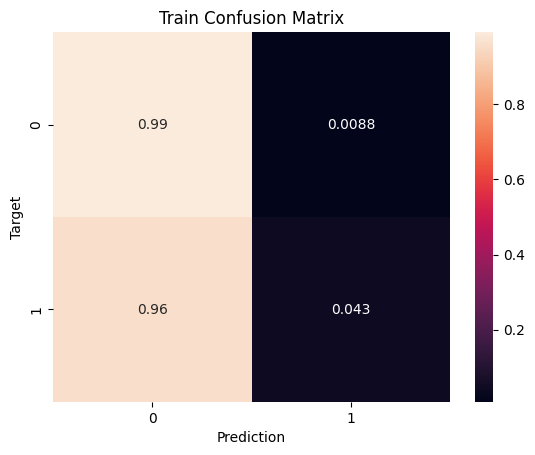

In [30]:
predict_and_plot(X_train, train_targets, 'Train')

Accuracy: 79.30%


array([0., 0., 0., ..., 0., 0., 0.])

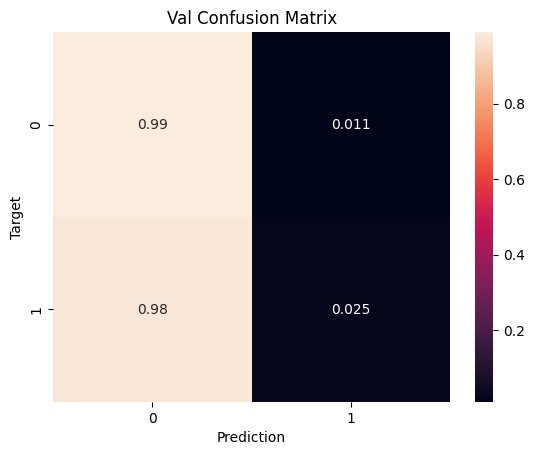

In [31]:
predict_and_plot(X_val, val_targets, 'Val')

Покращень не спостерігається, модель все ще погано вгадує. Показник аук на валідаційних даних незначно приріс порівняно з попереднім дослідження, але все ще результати моделі є поганими. Поведінка спостерігається все та ж - аук на тренованих становить понад 80%, а на валідаційних менше 60%

3. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn import metrics

In [33]:
tree = DecisionTreeClassifier(random_state=42)

In [34]:
params_grid = {
    'max_depth':np.arange(1,21,2),
    'max_leaf_nodes':np.arange(2,11,1)
}

In [35]:
search = GridSearchCV(
    tree,
    params_grid,
    scoring='roc_auc',
    cv = 3
)

In [36]:
%%time
search.fit(X_train, train_targets)

CPU times: user 4.37 s, sys: 541 µs, total: 4.37 s
Wall time: 4.4 s


GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]),
                         'max_leaf_nodes': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10])},
             scoring='roc_auc')

In [40]:
search.best_params_

{'max_depth': np.int64(5), 'max_leaf_nodes': np.int64(10)}

In [41]:
tree_best = search.best_estimator_

In [42]:
train_preds = tree_best.predict_proba(X_train)[:, 1]
auc_roc = roc_auc_score(train_targets, train_preds)

print(f"AUC-ROC Score for tree_best train: {auc_roc:.4f}")

AUC-ROC Score for tree_best train: 0.9015


In [43]:
val_preds = tree_best.predict_proba(X_val)[:, 1]
auc_roc = roc_auc_score(val_targets, val_preds)

print(f"AUC-ROC Score for tree_best val: {auc_roc:.4f}")

AUC-ROC Score for tree_best val: 0.9002


Дана модель являється хорошою - показники аук, що на тренувальних, що на валідаційних являються високими

4. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
    - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
    - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

In [44]:
from sklearn.model_selection import RandomizedSearchCV

In [45]:
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

In [46]:
tree = DecisionTreeClassifier(random_state=42)

In [47]:
random_search_tree = RandomizedSearchCV(
    tree,
    params_dt,
    n_iter=40,
    cv=3,
    scoring="roc_auc",
    random_state=42
)

In [48]:
%%time
random_search_tree.fit(X_train, train_targets)

CPU times: user 1.27 s, sys: 17 µs, total: 1.27 s
Wall time: 1.27 s


RandomizedSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
                   n_iter=40,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19]),
                                        'max_features': [None, 'sqrt', 'log2'],
                                        'max_leaf_nodes': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19]),
                                        'min_samples_leaf': [1, 2, 4, 8],
                                        'min_samples_split': [2, 5, 10, 20],
                                        'splitter': ['best', 'random']},
                   random_state=42, scoring='roc_auc')

In [49]:
random_search_tree.best_params_

{'splitter': 'best',
 'min_samples_split': 20,
 'min_samples_leaf': 2,
 'max_leaf_nodes': np.int64(14),
 'max_features': None,
 'max_depth': np.int64(16),
 'criterion': 'entropy'}

In [51]:
best_random_search_tree = random_search_tree.best_estimator_

In [52]:
train_preds = best_random_search_tree.predict_proba(X_train)[:, 1]
auc_roc = roc_auc_score(train_targets, train_preds)

print(f"AUC-ROC Score for tree_best train: {auc_roc:.4f}")

AUC-ROC Score for tree_best train: 0.9169


In [53]:
val_preds = best_random_search_tree.predict_proba(X_val)[:, 1]
auc_roc = roc_auc_score(val_targets, val_preds)

print(f"AUC-ROC Score for tree_best val: {auc_roc:.4f}")

AUC-ROC Score for tree_best val: 0.9166


Дана модель демонструє найкращі показники ефективності моделі (АУК) - спостерігається і на тренованих, і на валідаційних даних

5. Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

In [54]:
test_csv = data_dir + '/test.csv'
test_raw_df = pd.read_csv(test_csv)
test_raw_df

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,24995,15642997.0,Chukwumaobim,639.0,Spain,Male,38.0,10.0,0.00,2.0,1.0,1.0,49637.65
9996,24996,15739271.0,Clements,678.0,Spain,Male,39.0,9.0,0.00,2.0,1.0,1.0,142513.50
9997,24997,15756743.0,Chidiebere,774.0,France,Male,30.0,9.0,0.00,2.0,1.0,0.0,4861.72
9998,24998,15680167.0,Yermakova,595.0,France,Male,38.0,6.0,144875.79,1.0,1.0,0.0,126469.09


In [55]:
X_test, ids = pr.preprocess_new_data(
    new_df=test_raw_df,
    encoder=data['encoder'],
    scaler=data['scaler'],
    input_cols=data['input_cols'],
    numeric_cols=data['numeric_cols'],
    categorical_cols=data['categorical_cols']
)

In [56]:
preds = best_random_search_tree.predict_proba(X_test)[:,1]

In [57]:
sample_submission_csv = data_dir + '/sample_submission.csv'
sample_submission_df = pd.read_csv(sample_submission_csv)
sample_submission_df['Exited'] = preds
sample_submission_df

,id,Exited
0,15000,0.237911
1,15001,0.012115
2,15002,0.203947
3,15003,0.569848
4,15004,0.082171
...,...,...
9995,24995,0.012115
9996,24996,0.012115
9997,24997,0.012115
9998,24998,0.039301


In [58]:
sample_submission_df.to_csv("submission_log_reg.csv", index=False)

In [59]:
from google.colab import files
files.download("submission_log_reg.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

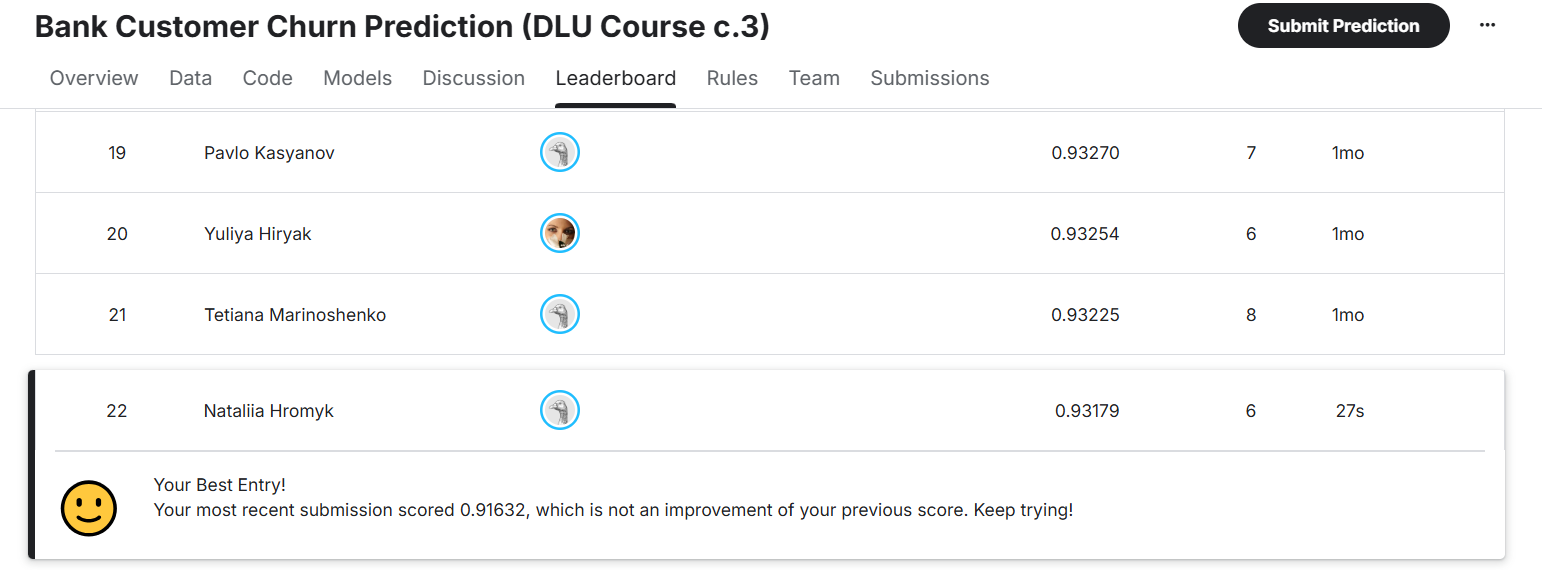)